In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# visualization setting
plt.style.use('default')
sns.set_style('whitegrid')

# display all columns
pd.set_option('display.max_columns',None)

In [4]:
# upload dataset
from google.colab import files
uploaded = files.upload()

Saving description.txt to description.txt
Saving test_data.txt to test_data.txt
Saving test_data_solution.txt to test_data_solution.txt
Saving train_data.txt to train_data.txt


In [8]:
# load train_data.txt
train_data = pd.read_csv(
    "train_data.txt",
    sep=" ::: ",
    engine="python",
    header=None,
    names=["ID","Title","Genre","Description"]
  )

In [10]:
# verify dataset
train_data.head()

,ID,Title,Genre,Description
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


In [11]:
# dataset informattion
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54214 entries, 0 to 54213
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           54214 non-null  int64 
 1   Title        54214 non-null  object
 2   Genre        54214 non-null  object
 3   Description  54214 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.7+ MB


In [12]:
# missing value
train_data.isnull().sum()

# no.of Genre
train_data["Genre"].nunique()

# Genre count
train_data["Genre"].value_counts()

# Word Count Statistics
train_data["word_count"] = train_data["Description"].str.split().apply(len)
train_data["word_count"].describe()

,word_count
count,54214.000000
mean,101.907386
std,76.579192
min,6.000000
25%,55.000000
50%,79.000000
75%,121.000000
max,1829.000000


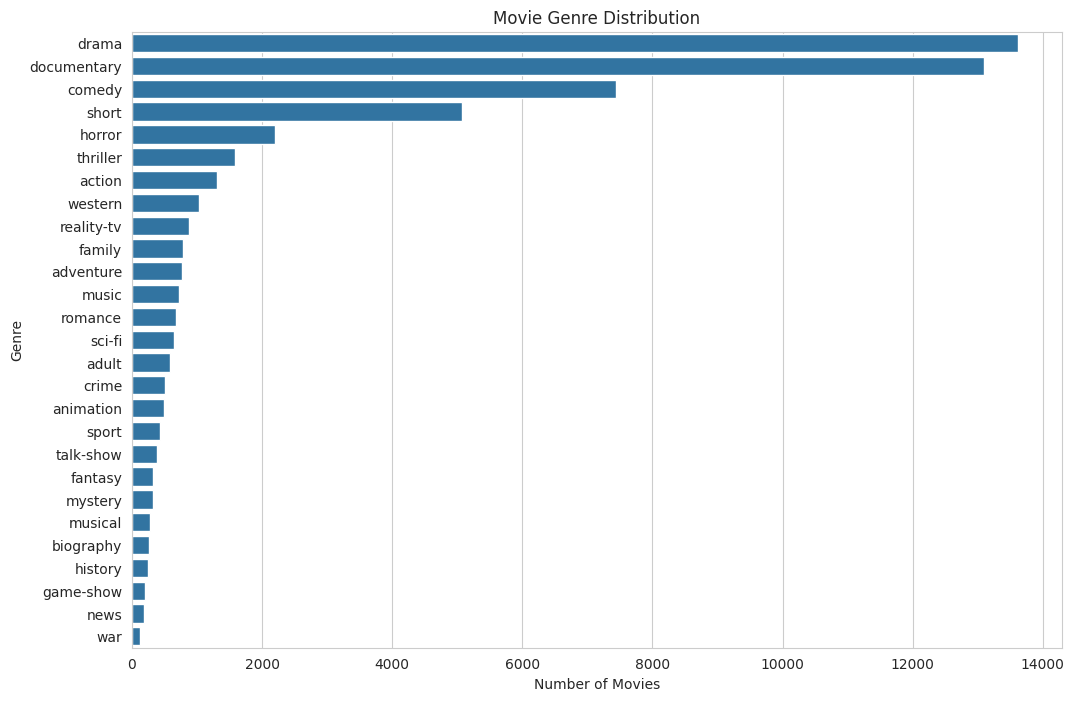

In [17]:
# Genre Distribution
plt.figure(figsize=(12,8))

genre_counts = train_data['Genre'].value_counts()

sns.barplot(
    x = genre_counts.values,
    y=genre_counts.index
)

plt.title("Movie Genre Distribution")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")

plt.show()

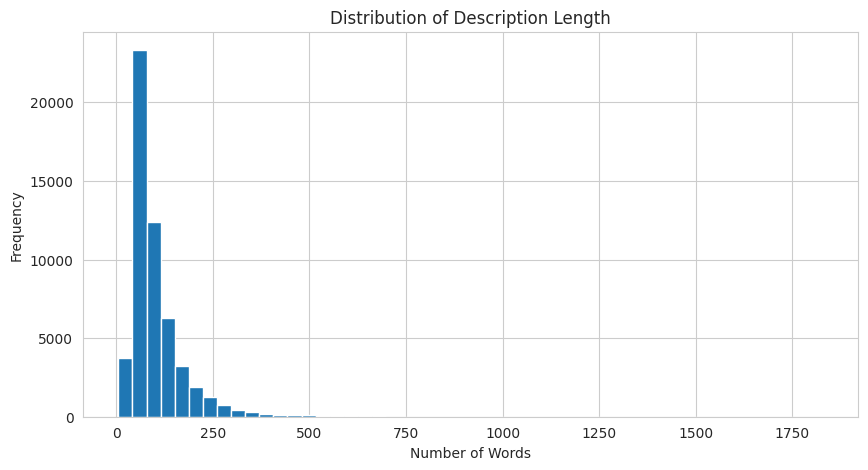

In [19]:
# word count distribution
plt.figure(figsize=(10,5))

plt.hist(train_data["word_count"], bins=50)

plt.title("Distribution of Description Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [21]:
# Longest description
train_data.loc[
    train_data["word_count"].idxmax(),
    ["Title","Genre","word_count"]
]

,2542
Title,East L.A. Marine: The Untold True Story of Guy...
Genre,documentary
word_count,1829


In [22]:
# short description
train_data.loc[
    train_data["word_count"].idxmin(),
    ["Title","Genre","word_count"]
]

,48605
Title,S'Ullestar s/n (1984)
Genre,short
word_count,6


In [ ]:
# # EDA Summary

# ## Dataset Overview

# - Total Records: **54,214**
# - Total Features: **4**
# - Missing Values: **None**
# - Input Feature: **Description**
# - Target Variable: **Genre**

# ## Genre Analysis

# - The dataset contains multiple movie genres.
# - Drama is the most represented genre.
# - Documentary and Comedy also have a large number of samples.
# - Some genres such as War, News, and Game-Show have comparatively fewer samples, indicating class imbalance.

# ## Description Analysis

# - Average description length: **~102 words**
# - Shortest description: **6 words**
# - Longest description: **1829 words**
# - Most movie descriptions fall between **50–150 words**.

# ## Conclusion

# The dataset is clean, well-structured, and suitable for building a multi-class movie genre classification model using Natural Language Processing techniques.